### Lab 06: SUPPORT VECTOR MACHINES (SVM) CLASSIFIER

### **Student Information**

- **Name:** Abdullah Farooq
- **Roll_no:** 24F-AI-050

#### Lab Tasks:

- Load a dataset for classification (e.g., Parkinson disease, Breast Cancer dataset).
- Apply data preprocessing (handle missing values, encode categorical data).
- Split the dataset into training and testing sets.
- Apply Grid search to find the optimal parameters
- Use those parameters to make predictions on the test set.
- Evaluate performance using accuracy, precision, recall, and F1-score.
- Visualize the Confusion Matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)

# Set standard plotting style
sns.set_theme(style="whitegrid")

In [2]:
plt.rcParams['figure.figsize'] = [4.4, 3.1]

plt.rcParams['figure.autolayout'] = True

In [3]:
# Task 1: Load Dataset

# Use the Breast Cancer dataset for classification
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

display(X.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# Task 2: Data Preprocessing

# no missing values
X.isnull().sum().sum()

np.int64(0)

In [7]:
# Task 3: Train-Test Split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Apply standard scaling to features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Task 4: Apply Grid Search for Optimal Parameters

print("--- Running Grid Search ---")
# Define the parameter grid testing different kernels (Linear, RBF, Poly) and C values
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'] # Primarily affects RBF and Poly kernels
}

# Apply Grid search to find the optimal parameters
svm_model = SVC(random_state=42)
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters Found: {grid_search.best_params_}")

--- Running Grid Search ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters Found: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [9]:
# Task 5: Make Predictions on the Test Set

# Use the best parameters to make predictions on the test set
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)

In [10]:
# Task 6: Evaluate Performance

# Evaluate performance using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- Support Vector Machine Performance Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))


--- Support Vector Machine Performance Metrics ---
Accuracy:  0.9825
Precision: 0.9726
Recall:    1.0000
F1-Score:  0.9861

Classification Report:

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



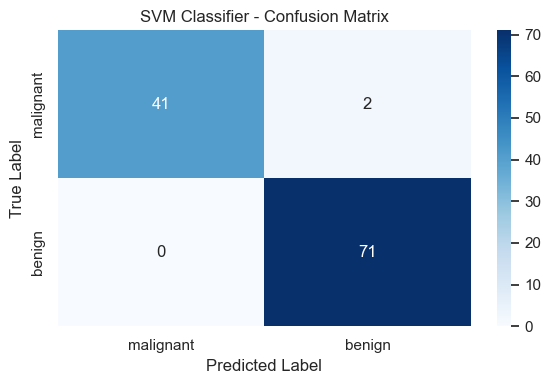

In [11]:
# Task 7: Visualize the Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=data.target_names, 
    yticklabels=data.target_names
)
plt.title("SVM Classifier - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()